**Longitudnal Sentiment Analysis**

Step 1 : Get news api key
Step 2 : News Collection Script


In [1]:
# Get your's news_api_key
news_api_key = "860584959ea04cfcaeb52f6e3eee3938"
news_api_key_2 = "045198cf95b440d38d403f9360f838d3"

In [ ]:
pip install requests pandas tqdm

**Basic News Collection Script**


*  API Key and Parameters: Sets up an API key and defines search parameters for
the News API, including search terms like 'robotaxi', 'autonomous taxi', 'Tesla', 'Waymo', and 'Cruise'
* Data Collection Loop: Iterates through up to 5 pages of News API results, making requests and handling potential errors
* Article Extraction: For each article retrieved, it extracts relevant details such as date, source, author, title, description, content, and URL
* Data Aggregation: Appends extracted article data to a list
* DataFrame Creation and Cleaning: Converts the collected data into a pandas DataFrame, transforms the 'date' column to datetime objects, and removes duplicate articles based on their URL
* CSV Export: Saves the final, cleaned DataFrame to a CSV file named 'robotaxi_news.csv'

In [ ]:
import requests
import pandas as pd
from datetime import datetime
import time

# ===============================
# ADD YOUR API KEY
# ===============================
api_key = news_api_key

# ===============================
# DEFINE SEARCH PARAMETERS
# ===============================
api_endpoint_url = "https://newsapi.org/v2/everything"

search_terms = '(robotaxi OR "autonomous taxi" OR "self-driving taxi" OR Tesla OR Waymo OR Cruise)'

params = {
    'q': search_terms,
    'language': 'en',
    'sortBy': 'publishedAt',
    'pageSize': 100,
    'apiKey': api_key
}

all_articles = []

print("Starting data collection...\n")

# ===============================
# LOOP THROUGH PAGES (1–5)
# ===============================
for page in range(1, 6):   # Free plan usually allows up to page 5
    print(f"Fetching page {page}...")

    params['page'] = page

    response = requests.get(api_endpoint_url, params=params)

    if response.status_code != 200:
        print("Error:", response.text)
        break

    data = response.json()

    if "articles" not in data:
        print("No articles found.")
        break

    articles = data["articles"]

    if len(articles) == 0:
        print("No more articles available.")
        break

    for article in articles:
        all_articles.append({
            "date": article["publishedAt"],
            "source": article["source"]["name"] if article["source"] else None,
            "author": article["author"],
            "title": article["title"],
            "description": article["description"],
            "content": article["content"],
            "url": article["url"]
        })

    time.sleep(1)  # avoid hitting API rate limits

print("\nData collection completed.")
print("Total articles collected:", len(all_articles))

# ===============================
# SAVE TO CSV
# ===============================

if len(all_articles) > 0:
    df = pd.DataFrame(all_articles)

    # Convert date column
    df["date"] = pd.to_datetime(df["date"])

    # Remove duplicates based on URL
    df = df.drop_duplicates(subset="url")

    df.to_csv("robotaxi_news.csv", index=False)

    print("Data saved to robotaxi_news.csv successfully!")
else:
    print("No data collected. CSV not created.")

Starting data collection...

Fetching page 1...
Fetching page 2...
Error: {"status":"error","code":"maximumResultsReached","message":"You have requested too many results. Developer accounts are limited to a max of 100 results. You are trying to request results 100 to 200. Please upgrade to a paid plan if you need more results."}

Data collection completed.
Total articles collected: 92
Data saved to robotaxi_news.csv successfully!


**Articles or Views collected from Reddit**

Currently my api key is not working for Reddit so I have not included that data.

#pip install praw pandas

Loading Kaggle News Datasets

In [ ]:
import pandas as pd
import zipfile

# Kaggle Dataset: Load News_Category_Dataset_v3.json.zip
with zipfile.ZipFile("News_Category_Dataset_v3.json.zip") as z:
    file_name = z.namelist()[0]
    df_json = pd.read_json(z.open(file_name), lines=True)

print("JSON Dataset Loaded")
print(df_json.columns)
print(df_json.head())


# Kaggle dataset - Load True.csv
df_true = pd.read_csv("True.csv")
print("\nTrue.csv Loaded")
print(df_true.columns)
print(df_true.head())


# Kaggle dataset: Load NewsDataset.csv
df_news = pd.read_csv("NewsDataset.csv")
print("\nNewsDataset.csv Loaded")
print(df_news.columns)
print(df_news.head())

JSON Dataset Loaded
Index(['link', 'headline', 'category', 'short_description', 'authors', 'date'], dtype='object')
                                                link  \
0  https://www.huffpost.com/entry/covid-boosters-...   
1  https://www.huffpost.com/entry/american-airlin...   
2  https://www.huffpost.com/entry/funniest-tweets...   
3  https://www.huffpost.com/entry/funniest-parent...   
4  https://www.huffpost.com/entry/amy-cooper-lose...   

                                            headline   category  \
0  Over 4 Million Americans Roll Up Sleeves For O...  U.S. NEWS   
1  American Airlines Flyer Charged, Banned For Li...  U.S. NEWS   
2  23 Of The Funniest Tweets About Cats And Dogs ...     COMEDY   
3  The Funniest Tweets From Parents This Week (Se...  PARENTING   
4  Woman Who Called Cops On Black Bird-Watcher Lo...  U.S. NEWS   

                                   short_description               authors  \
0  Health experts said it is too early to predict...  Carla K. Joh

Process JSON Dataset (df_json):

Creates a copy of the original df_json DataFrame.
Combines the 'headline' and 'short_description' columns into a new 'text' column.
Converts the 'date' column to datetime objects.
Adds a new 'source' column with the value 'HuffPost'.
Selects only the 'date', 'text', and 'source' columns for the cleaned JSON DataFrame.

Process True.csv Dataset (df_true):

Creates a copy of the original df_true DataFrame.
Combines the 'title' and 'text' columns into a new 'text' column.
Converts the 'date' column to datetime objects.
Adds a new 'source' column with the value 'Reuters'.
Selects only the 'date', 'text', and 'source' columns for the cleaned True.csv DataFrame.
Combine Datasets:


Combine Datasets:

Concatenates the two cleaned DataFrames (df_json_clean and df_true_clean) vertically into a single DataFrame called df_combined.
Prints the total number of articles in the combined dataset and displays the first few rows of df_combined.







In [ ]:
import pandas as pd

# ===============================
# Process JSON Dataset
# ===============================

df_json_clean = df_json.copy()

df_json_clean["text"] = df_json_clean["headline"] + " " + df_json_clean["short_description"]
df_json_clean["date"] = pd.to_datetime(df_json_clean["date"])
df_json_clean["source"] = "HuffPost"

df_json_clean = df_json_clean[["date", "text", "source"]]


# ===============================
# Process True.csv Dataset
# ===============================

df_true_clean = df_true.copy()

df_true_clean["text"] = df_true_clean["title"] + " " + df_true_clean["text"]
df_true_clean["date"] = pd.to_datetime(df_true_clean["date"])
df_true_clean["source"] = "Reuters"

df_true_clean = df_true_clean[["date", "text", "source"]]


# ===============================
# Combine Both
# ===============================

df_combined = pd.concat([df_json_clean, df_true_clean], ignore_index=True)

print("Total combined articles:", len(df_combined))
print(df_combined.head())

Total combined articles: 230944
        date                                               text    source
0 2022-09-23  Over 4 Million Americans Roll Up Sleeves For O...  HuffPost
1 2022-09-23  American Airlines Flyer Charged, Banned For Li...  HuffPost
2 2022-09-23  23 Of The Funniest Tweets About Cats And Dogs ...  HuffPost
3 2022-09-23  The Funniest Tweets From Parents This Week (Se...  HuffPost
4 2022-09-22  Woman Who Called Cops On Black Bird-Watcher Lo...  HuffPost


In [ ]:
df_api = pd.read_csv("robotaxi_news.csv")

print(df_api.columns)
print(df_api.head())

Index(['date', 'source', 'author', 'title', 'description', 'content', 'url'], dtype='object')
                        date             source         author  \
0  2026-02-24 20:25:13+00:00  Bringatrailer.com  bringatrailer   
1  2026-02-24 20:22:00+00:00     9to5google.com       Abner Li   
2  2026-02-24 20:05:06+00:00  Bringatrailer.com  bringatrailer   
3  2026-02-24 19:40:05+00:00  Bringatrailer.com  bringatrailer   
4  2026-02-24 19:35:07+00:00  Bringatrailer.com  bringatrailer   

                                               title  \
0  2,600-Mile 2020 GMC Sierra 1500 Crew Cab Denal...   
1  Waymo: Where it’s available, upcoming cities, ...   
2          2001 Toyota 4Runner SR5 4WD at No Reserve   
3                             1992 Acura NSX 5-Speed   
4      2000 Toyota Land Cruiser UZJ100 at No Reserve   

                                         description  \
0  This 2020 GMC Sierra 1500 Crew Cab is a short-...   
1  Waymo autonomous vehicles date back to Google’...   
2  T

In [ ]:
# Create unified text column
df_api["text"] = (
    df_api["title"].fillna("") + " " +
    df_api["description"].fillna("") + " " +
    df_api["content"].fillna("")
)

df_api["date"] = pd.to_datetime(df_api["date"])
df_api["source"] = "NewsAPI"

df_api_clean = df_api[["date", "text", "source"]]

print("NewsAPI cleaned:", len(df_api_clean))

NewsAPI cleaned: 92


Combining Kaggle news datasets and News API key data

In [ ]:
# Combine Kaggle + NewsAPI
df_master = pd.concat([df_combined, df_api_clean], ignore_index=True)

# Remove duplicates
df_master = df_master.drop_duplicates(subset=["text"])

print("Total Master Dataset Size:", len(df_master))

Total Master Dataset Size: 230325


In [ ]:
keywords = [
    "robotaxi",
    "autonomous taxi",
    "self-driving taxi",
    "Tesla",
    "Waymo",
    "Cruise",
    "autonomous vehicle"
]

pattern = "|".join(keywords)

df_robotaxi = df_master[df_master["text"].str.contains(pattern, case=False, na=False)]

print("Total Robotaxi Articles:", len(df_robotaxi))

Total Robotaxi Articles: 671


Longitudnal Sentiment Analysis Start

In [ ]:
pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.0 MB/s eta 0:00:00


In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import pandas as pd
import numpy as np

In [ ]:
analyzer = SentimentIntensityAnalyzer()

In [ ]:
def get_sentiment_scores(text):
    scores = analyzer.polarity_scores(str(text))
    return pd.Series([
        scores['neg'],
        scores['neu'],
        scores['pos'],
        scores['compound']
    ])

df_robotaxi[['neg', 'neu', 'pos', 'compound']] = df_robotaxi['text'].apply(get_sentiment_scores)

print(df_robotaxi.head())

                     date                                               text  \
1152  2022-02-19 00:00:00  Vladimir Putin Oversees Missile Tests Amid Ris...   
1320  2022-01-16 00:00:00  Norwegian Cruise Cancels Trip After 4 Days Of ...   
2084  2021-08-31 00:00:00  Dwayne 'The Rock' Johnson Is Shook At How Much...   
2121  2021-08-24 00:00:00  Carnival Cruise Passenger Dies Of COVID-19 Aft...   
2218  2021-08-07 00:00:00  The Pandemic Has Let Alaskan Whales Get Some P...   

        source    neg    neu    pos  compound  
1152  HuffPost  0.164  0.836  0.000   -0.5719  
1320  HuffPost  0.108  0.892  0.000   -0.4588  
2084  HuffPost  0.160  0.840  0.000   -0.6908  
2121  HuffPost  0.000  0.875  0.125    0.6915  
2218  HuffPost  0.000  0.892  0.108    0.5423  


/tmp/ipython-input-763/3048893457.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_robotaxi[['neg', 'neu', 'pos', 'compound']] = df_robotaxi['text'].apply(get_sentiment_scores)
/tmp/ipython-input-763/3048893457.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_robotaxi[['neg', 'neu', 'pos', 'compound']] = df_robotaxi['text'].apply(get_sentiment_scores)
/tmp/ipython-input-763/3048893457.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .

In [ ]:
#df_robotaxi['date'] = pd.to_datetime(df_robotaxi['date'])
df_robotaxi['date'] = pd.to_datetime(df_robotaxi['date'], utc=True, errors='coerce')
df_robotaxi['year'] = df_robotaxi['date'].dt.year
df_robotaxi['month'] = df_robotaxi['date'].dt.to_period('M')

/tmp/ipython-input-763/2405030189.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_robotaxi['date'] = pd.to_datetime(df_robotaxi['date'], utc=True, errors='coerce')
/tmp/ipython-input-763/2405030189.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_robotaxi['year'] = df_robotaxi['date'].dt.year
/tmp/ipython-input-763/2405030189.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_robotaxi['month'] = df_robotaxi['date'].dt.to_period('M')
/tmp/ipyth

In [ ]:
df_robotaxi['date'] = pd.to_datetime(df_robotaxi['date'], utc=True, errors='coerce')
df_robotaxi['date'] = df_robotaxi['date'].dt.tz_localize(None)

/tmp/ipython-input-763/743862805.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_robotaxi['date'] = pd.to_datetime(df_robotaxi['date'], utc=True, errors='coerce')
/tmp/ipython-input-763/743862805.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_robotaxi['date'] = df_robotaxi['date'].dt.tz_localize(None)


In [ ]:
yearly_sentiment = df_robotaxi.groupby('year')['compound'].mean().reset_index()

print(yearly_sentiment)

    year  compound
0   2012  0.207396
1   2013  0.313100
2   2014  0.225548
3   2015  0.077361
4   2016  0.151513
5   2017  0.005409
6   2018 -0.163325
7   2019 -0.470400
8   2020  0.223222
9   2021  0.083573
10  2022 -0.515350
11  2026 -0.121762


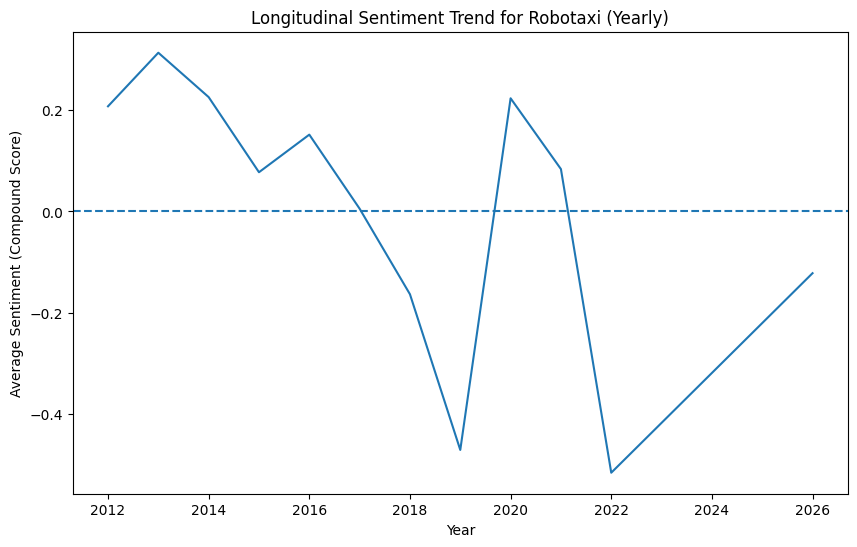

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(yearly_sentiment['year'], yearly_sentiment['compound'])
plt.title("Longitudinal Sentiment Trend for Robotaxi (Yearly)")
plt.xlabel("Year")
plt.ylabel("Average Sentiment (Compound Score)")
plt.axhline(0, linestyle='--')
plt.show()